# One-time held-out check of closure (R1) and the D3 link: evaluation assembler

This notebook is a demo of **`eval.py`** from the iteration-4 evaluation artifact of the AI Inventor study of emerging scientific concepts in evolving co-word networks. The study asks whether a concept's network structure *before* it emerges (closure, constraint, cross-community ties) predicts that it will emerge.

`eval.py` is the **final assembly step (S8)** of a one-look held-out evaluation. The expensive steps ran earlier, once, and were never re-run. Those steps were: opening the sealed R1 held-out fold, the D1 descriptive run, and the D3 bootstrap and permutation tests. Their outputs are small JSON/CSV/log files. `eval.py` reads them, never re-opens a sealed fold, and produces the following:

* **R1**: screen-vs-held-out tables for the event-study (S over k=-3..0) and pooled-panel `coef(futE)` rows. It then applies the **frozen kill mapping** (Holm family, which gives `R1_DEAD` / `R1_ALIVE…`) and the **frozen reading test** (`CONTRADICTED` / `SUPPORTED` / `SIGN_CONSISTENT` / `NOT_SUPPORTED`), and adds a descriptive inverse-variance synthesis and forest plot F1.
* **D1**: a descriptive held-out table next to the screen coefficients.
* **D3**: the early-closure → later-anchoring partial Spearman results, turned into examples.
* A short `results_note.md` paragraph, and `eval_out.json` (metrics + per-row examples).

Before assembling anything, the script checks that `eval_spec.json` and `d3_spec.json` still hash to the sha256 values logged when they were frozen.

**Data:** `mini_demo_data.json` bundles *every* input file `eval.py` reads (18 small files, about 210 KB), keyed by their original relative paths. The notebook writes them into a local working directory, so the original code runs **unchanged** apart from its root path. The computation is deterministic and CPU-only, and it takes a few seconds.

## Setup
Install dependencies. `loguru` is not pre-installed on Colab. The scientific stack is pinned to Colab's versions locally and is **not** reinstalled on Colab.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

Imports: the original import block of `eval.py`, plus `IPython.display` for showing the saved figure inline.

In [2]:
from __future__ import annotations

import hashlib
import json
import math
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy.stats import norm

# notebook-only extras (visualization)
from IPython.display import Image, Markdown, display

Data loading helper: fetch `mini_demo_data.json` from GitHub, falling back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-4/evaluation-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{len(data['files'])} bundled input files:")
for f in data["files"]:
    print(f"  [{f['format']:4}] {f['path']}")

Input bundle for eval.py (S8 ASSEMBLE) of gen_art_evaluation_3: every file the assembly script reads, keyed by its path relative to the original workspace. 'text' entries keep exact bytes (the two frozen specs are sha256-checked); 'json' entries are parsed for readability.
18 bundled input files:
  [text] eval_spec.json
  [text] d3_spec.json
  [text] logs/eval_freeze_log.jsonl
  [text] logs/s2_exp5_tests.log
  [text] logs/s2_exp6_tests.log
  [json] results/integrity_report.json
  [json] results/pre_open_power.json
  [json] results/d3/d3_results.json
  [json] results/d3/audit_d3.json
  [json] results/d3/audit_d3_calibration.json
  [json] results/r1/verdict_heldout.json
  [json] results/r1/r1_capture_balance.json
  [json] results/d1/confirmation.json
  [json] deps_run/exp5/heldout_spec.json
  [json] deps_run/exp5/results/event_study/primary_family.json
  [json] deps_run/exp5/results/confirm_selftest.json
  [json] deps_run/exp6/results/heldout/heldout_spec.json
  [text] deps_run/exp6/resu

## Config

`eval.py` has **no tunable compute parameters**: no iterations, samples or bootstrap draws. It only reassembles results that were computed once, earlier (for example, the 2,000-draw bootstrap and 10,000 Freedman–Lane permutations of D3 are already stored in `results/d3/d3_results.json`). The demo therefore runs at the **original, full scale**, which takes a few seconds.

The only settings are where the working directory goes and how much the summary cell prints.

In [5]:
WORK_DIR = Path("eval_workspace")   # stands in for the original artifact root (Path(__file__).parent)
SHOW_N_D3_ROWS = 50                 # D3 rows (primary + secondary + sensitivities) to plot/print; 50 covers all 22 (use e.g. 2 for primary only)

### Recreate the original workspace layout from `data`

This is the path fix. Every bundled file is written to `WORK_DIR/<original relative path>`, so the original readers (`jl(RES / "r1" / ...)`, `E5 / "heldout_spec.json"`, …) work unchanged. The two frozen spec files are stored as **raw text**, so their sha256 still matches `logs/eval_freeze_log.jsonl` and `check_frozen()` passes. JSON inputs were stored parsed (for readability) and are re-serialised here, which is harmless because they are only parsed, never hashed.

In [6]:
for f in data["files"]:
    p = WORK_DIR / f["path"]
    p.parent.mkdir(parents=True, exist_ok=True)
    if f["format"] == "json":
        p.write_text(json.dumps(f["content"], indent=1))
    else:
        p.write_text(f["content"])
print("materialised", len(data["files"]), "files under", WORK_DIR.resolve())

materialised 18 files under eval_workspace


## Paths, logging and constants

These lines are from the original script. The only change is `WS`: it pointed at `Path(__file__).resolve().parent` and now points at `WORK_DIR`. `E5` and `E6` are the vendored copies of the upstream experiments exp_5 (R1 event study) and exp_6 (D1).

* `CONF_ROWS`: every R1 row reported (closure variants, constraint, cross-community excess `xc_excess`, …).
* `HOLM_ROWS`: the 4-row confirmatory Holm family.
* `CODES`: the integer codes used for the string labels in `metrics_agg`.

In [7]:
WS = WORK_DIR.resolve()  # original: Path(__file__).resolve().parent
E5, E6 = WS / "deps_run" / "exp5", WS / "deps_run" / "exp6"
RES, TAB, FIG = WS / "results", WS / "results" / "tables", WS / "figures"

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(WS / "logs").mkdir(exist_ok=True)
logger.add(WS / "logs" / "eval.log", rotation="30 MB", level="DEBUG")

CONF_ROWS = ["closure", "closure_resT", "closure_persist", "constraint", "cdeg_diag", "xc_excess", "effsize", "wmz",
             "closure_resT_cc", "closure_resT_raw", "d_wmz", "d_closure"]
HOLM_ROWS = ["closure_resT", "closure_persist", "constraint", "closure"]
FOREST_ROWS = ["closure", "closure_resT", "closure_persist", "constraint", "xc_excess", "wmz", "cdeg_diag", "effsize"]
CODES = dict(
    r1_status={"R1_DEAD": 0, "R1_ALIVE": 1, "R1_ALIVE+TURNOVER_PROOF": 2, "R1_ALIVE+PERSISTENT": 3, "R1_ALIVE+TURNOVER_PROOF+PERSISTENT": 4},
    r1_reading_label={"CONTRADICTED": -1, "NOT_SUPPORTED": 0, "SIGN_CONSISTENT": 1, "SUPPORTED": 2},
    r1_verdict={"MIXED": 0, "BROKERAGE": 1, "TURNOVER": 2},
    d3_decision={"REVERSED": -1, "NULL": 0, "SCREEN_ONLY": 1, "KEPT": 2},
)

## Helpers
These are small utilities from the original script: JSON loading, NaN-safe float conversion, the `excl0` check for a CI excluding 0, number formatting, NaN→None cleaning for strict JSON, and a parser that counts passed pytest tests in a log.

In [8]:
# ----------------------------------------------------------------------------- helpers
def jl(p: Path) -> dict:
    return json.loads(p.read_text())


def fnum(x) -> float | None:
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if math.isfinite(v) else None


def excl0(ci) -> bool:
    lo, hi = fnum(ci[0]), fnum(ci[1])
    return lo is not None and hi is not None and (lo > 0 or hi < 0)


def fmt(x, d=3) -> str:
    v = fnum(x)
    return "NA" if v is None else f"{v:+.{d}f}"


def fci(ci, d=3) -> str:
    return f"[{fmt(ci[0], d)}, {fmt(ci[1], d)}]"


def clean(o):
    """Recursively replace NaN/inf by None so the JSON is standard."""
    if isinstance(o, dict):
        return {k: clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (float, np.floating)):
        return float(o) if math.isfinite(o) else None
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o


def pytest_passed(p: Path) -> int:
    mt = re.search(r"(\d+) passed", p.read_text())
    return int(mt.group(1)) if mt else 0

### Freeze check

The script **refuses to run** if either frozen spec changed after the freeze. It recomputes the sha256 of `eval_spec.json` and `d3_spec.json` and compares each against the hash logged when the file was frozen.

In [9]:
def check_frozen() -> dict:
    out = {}
    logged = {}
    for line in (WS / "logs" / "eval_freeze_log.jsonl").read_text().splitlines():
        r = json.loads(line)
        logged[r["file"]] = (r["sha256"], r["utc_iso"])
    for f in ("eval_spec.json", "d3_spec.json"):
        h = hashlib.sha256((WS / f).read_bytes()).hexdigest()
        if h != logged[f][0]:
            raise SystemExit(f"REFUSED: {f} changed after freeze")
        out[f] = dict(sha256=h, frozen_utc=logged[f][1])
    return out

## R1: assemble the sealed held-out readout

`r1_assemble` compares the screen fold (exp_5 `primary_family.json`) with the one-look held-out verdict (`verdict_heldout.json`):

1. **R1-1 event-study rows.** S and CI on the screen and on the held-out fold, the one-sided p in the pre-registered direction, whether the sign agrees, and the MDE.
2. **R1-2 pooled-panel rows.** `coef(futE)` ± 1.96·SE and a two-sided p.
3. **R1-3 / R1-7 kill mapping.** R1 is ALIVE only if raw `closure` is Holm-CONFIRMED. `+TURNOVER_PROOF` and `+PERSISTENT` are then added for `closure_resT` and `closure_persist`.
4. **R1-8 reading test.** The frozen precedence is CONTRADICTED → SUPPORTED → SIGN_CONSISTENT → NOT_SUPPORTED, based on the signs and CIs of `constraint` and `xc_excess`.
5. **R1-5 sample accounting.** Onsets, matches, and the pre-declared fallback to screen never-controls.
6. **R1-9 inverse-variance synthesis.** Screen and held-out are pooled, with Cochran's Q and I². This is labelled *descriptive, not a decision*.

It writes the CSV tables and `results/r1/r1_summary.json`.

In [10]:
def r1_assemble(power: dict) -> dict:
    spec = jl(E5 / "heldout_spec.json")
    pf = jl(E5 / "results" / "event_study" / "primary_family.json")
    st = jl(E5 / "results" / "confirm_selftest.json")
    v = jl(RES / "r1" / "verdict_heldout.json")
    cap = jl(RES / "r1" / "r1_capture_balance.json")
    dirs = spec["directions"]
    # R1-1 event-study rows
    es_rows = []
    for r in CONF_ROWS:
        s, h = pf["rows"][r]["primary"], v["rows"][r]
        d = dirs.get(r)
        pkey = "p_one_neg" if d == "negative" else ("p_one_pos" if d == "positive" else None)
        es_rows.append(dict(row=r, spec_direction=d or "none (descriptive)", estimator_frozen=spec["estimator_per_row"].get(r, "event_study"),
                            S_screen=s["S"], ci_screen_lo=s["ci"][0], ci_screen_hi=s["ci"][1],
                            p_one_screen=s.get(pkey) if pkey else None,
                            S_heldout=h["S"], ci_heldout_lo=h["ci"][0], ci_heldout_hi=h["ci"][1],
                            p_one_heldout=h.get(pkey) if pkey else None, p_two_heldout=h.get("p"),
                            same_sign=bool(np.sign(s["S"]) == np.sign(h["S"])) if fnum(h["S"]) is not None else None,
                            ci_heldout_excludes_0=excl0(h["ci"]),
                            mde_es=spec["mde_table"].get(r, {}).get("event_study")))
    # R1-2 pooled panel rows
    pp_rows = []
    for r in CONF_ROWS:
        h = v["panel"].get(r, {})
        sp = st["panel"].get(r) or pf["pooled_panel"].get(r) or {}
        d = dirs.get(r)
        pkey = "p_one_neg" if d == "negative" else ("p_one_pos" if d == "positive" else None)
        z = (fnum(h.get("coef")) / fnum(h.get("se"))) if fnum(h.get("se")) else None
        pp_rows.append(dict(row=r, spec_direction=d or "none (descriptive)", coef_screen=sp.get("coef"), se_screen=sp.get("se"),
                            coef_heldout=h.get("coef"), se_heldout=h.get("se"),
                            ci_heldout_lo=(h["coef"] - 1.96 * h["se"]) if fnum(h.get("se")) else None,
                            ci_heldout_hi=(h["coef"] + 1.96 * h["se"]) if fnum(h.get("se")) else None,
                            p_one_heldout=h.get(pkey) if pkey else None,
                            p_two_heldout=float(2 * norm.sf(abs(z))) if z is not None else None,
                            n_concept_years=h.get("n"), n_concepts=h.get("n_concepts"),
                            mde_panel=spec["mde_table"].get(r, {}).get("pooled_panel")))
    # R1-3 Holm tests (verbatim from the script)
    tests = v["tests"]
    # R1-4 verdict
    det = v["verdict_detail"]
    S_raw, S_res = v["rows"]["closure"]["S"], v["rows"]["closure_resT"]["S"]
    retention = abs(S_res) / abs(S_raw) if fnum(S_raw) else None
    # R1-7 kill mapping (frozen in eval_spec.json)
    alive = tests["closure"]["decision"] == "CONFIRMED"
    status = "R1_DEAD"
    if alive:
        status = "R1_ALIVE"
        if tests["closure_resT"]["decision"] == "CONFIRMED":
            status += "+TURNOVER_PROOF"
        if tests["closure_persist"]["decision"] == "CONFIRMED":
            status += "+PERSISTENT"
    reversed_ = bool(fnum(tests["closure"]["coef"]) is not None and tests["closure"]["coef"] > 0)
    # R1-8 reading test (frozen precedence: CONTRADICTED, SUPPORTED, SIGN_CONSISTENT, NOT_SUPPORTED)
    c, x = v["rows"]["constraint"], v["rows"]["xc_excess"]
    clo = tests["closure"]["coef"] < 0
    comp = dict(closure_coef_neg=bool(clo), closure_confirmed=bool(alive), S_constraint_pos=bool(c["S"] > 0),
                S_xc_excess_pos=bool(x["S"] > 0),
                constraint_ci_excludes_0_pos=bool(c["ci"][0] > 0), xc_excess_ci_excludes_0_pos=bool(x["ci"][0] > 0),
                constraint_ci_excludes_0_neg=bool(c["ci"][1] < 0), xc_excess_ci_excludes_0_neg=bool(x["ci"][1] < 0))
    if comp["constraint_ci_excludes_0_neg"] or comp["xc_excess_ci_excludes_0_neg"]:
        reading = "CONTRADICTED"
    elif clo and alive and comp["S_constraint_pos"] and comp["S_xc_excess_pos"] and (comp["constraint_ci_excludes_0_pos"] or comp["xc_excess_ci_excludes_0_pos"]):
        reading = "SUPPORTED"
    elif clo and comp["S_constraint_pos"] and comp["S_xc_excess_pos"] and not (comp["constraint_ci_excludes_0_pos"] or comp["xc_excess_ci_excludes_0_pos"]):
        reading = "SIGN_CONSISTENT"
    else:
        reading = "NOT_SUPPORTED"
    held = [k for k, val in comp.items() if val and not k.endswith("_neg")]
    reading_note = (f"components holding on held-out: {held}; the frozen rule needs closure CONFIRMED for SUPPORTED and "
                    "'neither CI excludes 0' for SIGN_CONSISTENT")
    # R1-5 sample accounting
    exp_n = spec["expected_heldout_n"]
    na = cap.get("closure_persist_na") or {}
    acct = dict(n_onsets=v["n_onsets"], n_matched=v["n_matched"], match_rate=v["n_matched"] / v["n_onsets"] if v["n_onsets"] else None,
                n_never_controls_pool=cap["run_fold_calls"][-1]["n_never"], n_matched_before_fallback=cap["run_fold_calls"][0]["n_matched"],
                n_never_before_fallback=cap["run_fold_calls"][0]["n_never"],
                fallback_screen_controls=v["fallback_screen_controls"], n_unique_controls=cap["n_unique_controls"],
                controls_from_heldout=cap["controls_from_heldout"], controls_from_screen=cap["controls_from_screen"],
                matched_treated_with_any_screen_control=cap["matched_treated_with_any_screen_control"],
                widened_share=cap.get("widened_share"), mean_controls_per_matched=cap.get("mean_controls_per_matched"),
                closure_persist_window_treated_na=na.get("window_treated_na"), closure_persist_window_control_na=na.get("window_control_na"),
                closure_persist_n_treated_finite=na.get("n_treated_with_finite_in_window"),
                H_matched_n=det["inputs"].get("n_matched_H"), H_matched_S_closure_resT=det["inputs"].get("S_res_H_matched"),
                H_matched_ci=det["inputs"].get("ci_res_H_matched"),
                expected_heldout_n=exp_n, n_matched_within_expected_band=bool(exp_n["band80"][0] <= v["n_matched"] <= exp_n["band80"][1]),
                screen_n_onsets=pf["n_onsets"], screen_n_matched=pf["n_matched"], screen_match_rate=pf["match_rate"])
    # R1-9 IV synthesis (descriptive)
    iv = []
    for r in FOREST_ROWS:
        s, h = pf["rows"][r]["primary"], v["rows"][r]
        Ss, Sh = fnum(s["S"]), fnum(h["S"])
        ses = (s["ci"][1] - s["ci"][0]) / 3.92 if fnum(s["ci"][0]) is not None else None
        seh = (h["ci"][1] - h["ci"][0]) / 3.92 if fnum(h["ci"][0]) is not None else None
        if None in (Ss, Sh, ses, seh) or ses <= 0 or seh <= 0:
            continue
        w = np.array([1 / ses ** 2, 1 / seh ** 2])
        est = float((w * np.array([Ss, Sh])).sum() / w.sum())
        se = float(1 / math.sqrt(w.sum()))
        Q = float((w * (np.array([Ss, Sh]) - est) ** 2).sum())
        I2 = max(0.0, (Q - 1) / Q) if Q > 0 else 0.0
        iv.append(dict(row=r, S_screen=Ss, se_screen=ses, S_heldout=Sh, se_heldout=seh, S_pooled=est, se_pooled=se,
                       ci_lo=est - 1.96 * se, ci_hi=est + 1.96 * se, cochran_Q=Q, p_Q=float(1 - __import__("scipy").stats.chi2.cdf(Q, 1)),
                       I2=I2, label="DESCRIPTIVE, NOT A DECISION"))
    out = dict(spec_sha256=v["spec_sha256"], status=status, reversed=reversed_, reading_label=reading, reading_components=comp,
               reading_note=reading_note, verdict=v["verdict_rule_on_heldout"], verdict_flags=det.get("flags"),
               verdict_brokerage_conditions=det.get("brokerage"), verdict_turnover_conditions=det.get("turnover"),
               retention_abs_Sres_over_abs_Sraw=retention, screen_retention=abs(pf["rows"]["closure_resT"]["primary"]["S"]) / abs(pf["rows"]["closure"]["primary"]["S"]),
               tests=tests, es_rows=es_rows, panel_rows=pp_rows, accounting=acct, balance_smd=cap["smd_screen_sd"],
               balance_vendored=cap["smd_vendored"], iv_synthesis=iv, projected_power=power["R1"]["rows"],
               constraint_note="constraint is tested in the pre-registered NEGATIVE (brokerage) direction; a positive held-out "
                               "constraint is DEAD by construction",
               disclosures=["E_up was promoted post hoc in iteration 2 (the primary E gave 4 onsets)",
                            f"screen match rate {pf['n_matched']}/{pf['n_onsets']} = {pf['match_rate']:.0%}",
                            f"held-out fallback to screen never controls triggered: {v['fallback_screen_controls']} "
                            f"({cap['run_fold_calls'][0]['n_matched']} matched before, {v['n_matched']} after; "
                            f"{cap['controls_from_screen']} of {cap['n_unique_controls']} unique event-study controls are screen concepts; the "
                            f"pooled panel is built from the same enlarged never set, so it also contains "
                            f"{acct['n_never_controls_pool'] - acct['n_never_before_fallback']} screen never-concepts "
                            f"(all futE = 1 rows are held-out); neither estimator is control-side independent of the screen)",
                            "confirm_heldout.py was invoked through a Python import + recorder wrapper (r1_open_once.py), not the CLI; "
                            "its bytes and hashes were unchanged (integrity_report.json) and confirm() ran exactly once",
                            "the wrapper's own post-processing crashed AFTER the verdict was written (duplicate reference-concept "
                            "rows in the fallback feature frame); balance was computed from the recorded capture by r1_balance.py "
                            "without re-opening (logs/r1_attempts.jsonl, deviations.md)"])
    TAB.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(es_rows).to_csv(TAB / "r1_event_study_screen_vs_heldout.csv", index=False)
    pd.DataFrame(pp_rows).to_csv(TAB / "r1_pooled_panel_screen_vs_heldout.csv", index=False)
    pd.DataFrame([dict(row=k, **t) | {"ci": t.get("ci")} for k, t in tests.items()]).to_csv(TAB / "r1_holm_decisions.csv", index=False)
    pd.DataFrame(cap["smd_screen_sd"]).to_csv(TAB / "r1_balance_smd.csv", index=False)
    pd.DataFrame(iv).to_csv(TAB / "r1_iv_synthesis_descriptive.csv", index=False)
    pd.DataFrame([dict(step=k, value=json.dumps(val) if isinstance(val, (dict, list)) else val) for k, val in acct.items()]).to_csv(TAB / "r1_n_flow.csv", index=False)
    (RES / "r1" / "r1_summary.json").write_text(json.dumps(clean(out), indent=1))
    return out

### Forest plot F1

The first 8 panels show event-study S (screen in blue, held-out in red) with the ±MDE band in grey. The last 4 show the pooled-panel `coef(futE)` for the Holm family, with each row's Holm p and decision in the panel title. The figure is saved to `figures/F1_r1_forest.png`. The original uses the `Agg` backend, and the summary section below displays the saved PNG.

In [11]:
def r1_forest(r1: dict, spec: dict) -> None:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    es = {r["row"]: r for r in r1["es_rows"]}
    pp = {r["row"]: r for r in r1["panel_rows"]}
    fig, axes = plt.subplots(3, 4, figsize=(13, 8.5))
    axes = axes.ravel()
    for i, r in enumerate(FOREST_ROWS):
        ax = axes[i]
        e = es[r]
        mde = spec["mde_table"].get(r, {}).get("event_study")
        if mde:
            ax.axvspan(-mde, mde, color="0.9", zorder=0, label="+-MDE (80%)")
        for j, (lab, S, lo, hi, col) in enumerate([("screen", e["S_screen"], e["ci_screen_lo"], e["ci_screen_hi"], "tab:blue"),
                                                   ("held-out", e["S_heldout"], e["ci_heldout_lo"], e["ci_heldout_hi"], "tab:red")]):
            if fnum(S) is None:
                continue
            ax.errorbar([S], [1 - j], xerr=[[S - lo], [hi - S]], fmt="o", color=col, capsize=3, label=lab)
        ax.axvline(0, color="k", lw=0.7)
        ax.set_yticks([1, 0], ["screen", "held-out"])
        ax.set_ylim(-0.7, 1.7)
        d = e["spec_direction"]
        ax.set_title(f"ES S: {r}  (spec dir: {d.split(' ')[0]})", fontsize=9)
    for i, r in enumerate(HOLM_ROWS):
        ax = axes[8 + i]
        p = pp[r]
        mde = spec["mde_table"].get(r, {}).get("pooled_panel")
        if mde:
            ax.axvspan(-mde, mde, color="0.9", zorder=0)
        t = r1["tests"][r]
        est = t["estimator"]
        rows = [("screen", p["coef_screen"], p["se_screen"], "tab:blue"), ("held-out", p["coef_heldout"], p["se_heldout"], "tab:red")]
        for j, (lab, b, se, col) in enumerate(rows):
            if fnum(b) is None or fnum(se) is None:
                continue
            ax.errorbar([b], [1 - j], xerr=[[1.96 * se], [1.96 * se]], fmt="s", color=col, capsize=3)
        ax.axvline(0, color="k", lw=0.7)
        ax.set_yticks([1, 0], ["screen", "held-out"])
        ax.set_ylim(-0.7, 1.7)
        ax.set_title(f"panel coef(futE): {r}\nprimary={est}; Holm p={t['p_one_holm']:.3f} {t['decision']}", fontsize=8)
    axes[0].legend(fontsize=7, loc="lower left")
    fig.suptitle(f"F1. R1 screen vs sealed held-out (one look). Status {r1['status']}; verdict {r1['verdict']}; "
                 f"reading test {r1['reading_label']}", fontsize=11)
    fig.tight_layout()
    FIG.mkdir(exist_ok=True)
    fig.savefig(FIG / "F1_r1_forest.png", dpi=150)
    fig.savefig(FIG / "F1_r1_forest.pdf")
    plt.close(fig)

## D1: descriptive held-out table

D1 was **not supported on the screen**, so its held-out run is descriptive only. For each openness measure × W2 outcome cell, this function puts the held-out coefficient, the concept-cluster bootstrap CI and the transfer ΔR² next to the exp_6 screen coefficient, and records whether the signs agree.

In [12]:
# ----------------------------------------------------------------------------- D1
def d1_assemble() -> dict:
    conf = jl(RES / "d1" / "confirmation.json")
    spec6 = jl(E6 / "results" / "heldout" / "heldout_spec.json")
    scr = pd.read_csv(E6 / "results" / "d1" / "coef_table_primary.csv")
    scr = scr[(scr.model == "a_primary_OLS") & (scr.population == "MAIN")].set_index(["openness", "outcome"])
    rows = []
    for m, per in conf["estimates"].items():
        for y, r in per.items():
            s = scr.loc[(m, y)] if (m, y) in scr.index else None
            sdy = float(s.sd_y) if s is not None else None
            tr = r.get("transfer", {})
            coef = r.get("coef")
            rows.append(dict(openness=m, outcome=y, coef_heldout=coef, ci_lo=r.get("ci_lo"), ci_hi=r.get("ci_hi"), p_boot=r.get("p_boot"),
                             n_rows=r.get("n_rows"), n_concepts=r.get("n_concepts"),
                             coef_heldout_in_screen_sd_y=(coef / sdy) if (sdy and fnum(coef) is not None) else None,
                             mde_heldout_sd=spec6["mde"].get(m, {}).get(y, {}).get("mde_heldout_sd"),
                             transfer_mde_sd=spec6["mde"].get(m, {}).get(y, {}).get("transfer_mde_sd"),
                             coef_screen=float(s.coef) if s is not None else None,
                             ci_screen_lo=float(s.ci_lo) if s is not None else None, ci_screen_hi=float(s.ci_hi) if s is not None else None,
                             sign_agreement_descriptive=bool(np.sign(coef) == np.sign(float(s.coef))) if (s is not None and fnum(coef) is not None) else None,
                             transfer_delta_r2=tr.get("delta_r2"), transfer_ci_lo=tr.get("ci_lo"), transfer_ci_hi=tr.get("ci_hi"),
                             transfer_r2_base=tr.get("r2_base"), transfer_r2_full=tr.get("r2_full")))
    pd.DataFrame(rows).to_csv(TAB / "d1_heldout_descriptive.csv", index=False)
    return dict(status=conf["status"], spec_sha256=conf["spec_sha256"], carried_outcomes=conf["carried_outcomes"], rows=rows)

## Results note and `eval_out.json`

`results_note` writes the paragraph used in the paper. That paragraph covers the R1 status under the frozen kill mapping, what it means for the Cheng et al. (2023) vs Salatino et al. (2017) tension, and the D3 decision (whether "one mechanism at two scales" is kept or dropped).

`eval_out` builds the `exp_eval_sol_out` JSON, which has three parts:
* `metrics_agg`: labels coded as integers, D3 partial rho, CIs and p-values, R1 accounting, Holm p-values, balance SMDs, D1 coefficients, and the integrity / pytest counts.
* `datasets`: one example per R1 row, D1 cell and D3 analysis (primary, secondary and sensitivities S1–S8 with n ≥ 10).
* `metadata`: spec hashes, freeze times, disclosures.

In [13]:
# ----------------------------------------------------------------------------- note + eval_out
def results_note(r1: dict, d3: dict) -> str:
    t = r1["tests"]
    c = next(r for r in r1["es_rows"] if r["row"] == "constraint")
    x = next(r for r in r1["es_rows"] if r["row"] == "xc_excess")
    pc = t["closure"]
    head = (f"**Held-out R1 (one look, spec {r1['spec_sha256'][:8]}).** Under the kill mapping frozen before opening, R1 is "
            f"**{r1['status']}**: the raw-closure pooled-panel coefficient keeps its negative sign ({fmt(pc['coef'])}, one-sided "
            f"p = {pc['p_one']:.3f}) but fails Holm (p = {pc['p_one_holm']:.3f}); closure_resT is DEAD (Holm p = "
            f"{t['closure_resT']['p_one_holm']:.3f}); and persistent-neighbour closure is CONFIRMED on the held-out fold "
            f"({fmt(t['closure_persist']['coef'])}, Holm p = {t['closure_persist']['p_one_holm']:.3f}). The mechanical verdict is "
            f"{r1['verdict']} again, and the reading test is {r1['reading_label']}. Constraint is positive once more, "
            f"S = {fmt(c['S_heldout'])} {fci([c['ci_heldout_lo'], c['ci_heldout_hi']])}, and xc_excess is "
            f"S = {fmt(x['S_heldout'])} {fci([x['ci_heldout_lo'], x['ci_heldout_hi']])}."
            + (" Caveat: the pre-declared fallback fired (fewer than 20 matched), so both estimators also use screen "
               "never-concepts as controls." if r1["accounting"]["fallback_screen_controls"] else ""))
    if r1["status"] == "R1_DEAD":
        body = (" Because raw closure does not survive Holm, the claimed tension between Cheng et al. (2023), where ideas become core "
                "through focused discourse and a fit with existing traditions (i.e. higher constraint), and Salatino et al. "
                "(2017), where cross-fertilisation of weakly connected areas precedes emergence (sparse, cross-community "
                "associates), is moot as a confirmed RQ1 finding. It survives only as a descriptive pattern: "
                "the redundant wider ego network (constraint > 0, replicated with CI excluding 0) is closer to Cheng et al., "
                "and the persistent top neighbours being less closed is closer to Salatino et al. "
                "The RQ1 sentence therefore becomes 'structural precursors are volume/churn correlates', qualified by the "
                "confirmed persistent-neighbour row.")
    else:
        body = (" The held-out pattern keeps both halves of the synthesis: a redundant wider ego network (Cheng et al. 2023, focused "
                "discourse and a fit with traditions) around sparsely closed, cross-community top associates (Salatino et al. 2017, "
                "pre-emergence cross-fertilisation of weakly connected areas). The two accounts are therefore complementary scales, "
                "not rivals.")
    dd = d3["decision"]["decision"]
    ps, ph = d3["primary"]["screen"], d3["primary"]["heldout"]
    tail = (f" D3 is **{dd}**: partial rho = {fmt(ps['partial_rho'])} {fci(ps['ci'])} on the screen (n = {ps['n']}, p = "
            f"{ps['p_one_neg']:.2f}) and {fmt(ph['partial_rho'])} {fci(ph['ci'])} on the held-out fold (n = {ph['n']}, MDE "
            f"{ph['mde_rho']:.2f}). The 'one mechanism at two scales' sentence is "
            f"{'kept' if dd == 'KEPT' else 'dropped, and the paper reports RQ1 and RQ2-D2 as separate findings'}.")
    return head + body + tail


def eval_out(r1: dict, d1: dict, d3: dict, integ: dict, frozen: dict, power: dict) -> dict:
    t = r1["tests"]
    ps, ph = d3["primary"]["screen"], d3["primary"]["heldout"]
    acct = r1["accounting"]
    smd = {f"{r['covariate']}_k{r['k']}".replace("-", "m"): r["smd"] for r in r1["balance_smd"]}
    m = dict(
        r1_status=CODES["r1_status"][r1["status"]], r1_reversed=int(r1["reversed"]),
        r1_reading_label=CODES["r1_reading_label"][r1["reading_label"]], r1_verdict=CODES["r1_verdict"][r1["verdict"]],
        d3_decision=CODES["d3_decision"][d3["decision"]["decision"]],
        d3_partial_rho_screen=ps["partial_rho"], d3_partial_rho_heldout=ph["partial_rho"],
        d3_p_one_screen=ps["p_one_neg"], d3_p_one_heldout=ph["p_one_neg"],
        d3_ci_lo_screen=ps["ci"][0], d3_ci_hi_screen=ps["ci"][1], d3_ci_lo_heldout=ph["ci"][0], d3_ci_hi_heldout=ph["ci"][1],
        d3_raw_rho_screen=ps["raw_rho"], d3_raw_rho_heldout=ph["raw_rho"], d3_n_screen=ps["n"], d3_n_heldout=ph["n"],
        d3_mde_screen=ps["mde_rho"], d3_mde_heldout=ph["mde_rho"],
        d3_heldout_power_at_screen_rho=d3.get("heldout_power_at_screen_rho"),
        r1_n_onsets=acct["n_onsets"], r1_n_matched=acct["n_matched"], r1_match_rate=acct["match_rate"],
        r1_n_matched_before_fallback=acct["n_matched_before_fallback"], r1_fallback=int(bool(acct["fallback_screen_controls"])),
        r1_retention_ratio=r1["retention_abs_Sres_over_abs_Sraw"],
        r1_n_smd_flagged=sum(1 for r in r1["balance_smd"] if r["flag_abs_gt_0_25"]),
        integrity_all_ok=int(integ["all_ok"]), integrity_n_checks=sum(p["n_checked"] for p in integ["parts"].values()),
        integrity_n_ok=sum(p["n_ok"] for p in integ["parts"].values()),
        pytest_exp5_passed=pytest_passed(WS / "logs" / "s2_exp5_tests.log"),
        pytest_exp6_passed=pytest_passed(WS / "logs" / "s2_exp6_tests.log"), r1_selftest_passed=int(jl(E5 / "results" / "confirm_selftest.json")["passed"]),
        spend_usd=0.0,
    )
    aud = RES / "d3" / "audit_d3.json"
    if aud.exists():
        a = jl(aud)
        m["d3_audit_pass"] = int(all(v["pass"] for v in a.values()))
        m["d3_audit_max_abs_diff"] = max(v["abs_diff"] for v in a.values())
    cal = RES / "d3" / "audit_d3_calibration.json"
    if cal.exists():
        m["d3_perm_null_share_p_lt_005"] = jl(cal)["share_p_lt_005"]
    for r in HOLM_ROWS:
        m[f"r1_{r}_p_one_holm"] = t[r]["p_one_holm"]
        m[f"r1_{r}_confirmed"] = int(t[r]["decision"] == "CONFIRMED")
        est = t[r].get("coef", t[r].get("S"))
        m[f"r1_{r}_heldout_estimate"] = est
    for e in r1["es_rows"]:
        m[f"r1_es_S_heldout_{e['row']}"] = e["S_heldout"]
    for k, val in smd.items():
        m[f"r1_smd_{k}"] = val
    for r in d1["rows"]:
        m[f"d1_coef_{r['openness']}_{r['outcome']}"] = r["coef_heldout"]
    m = {k: v for k, v in clean(m).items() if v is not None}
    # ---------------- examples
    ds_r1 = []
    es = {r["row"]: r for r in r1["es_rows"]}
    pp = {r["row"]: r for r in r1["panel_rows"]}
    for r in CONF_ROWS:
        e, p = es[r], pp[r]
        tt = t.get(r)
        ex = dict(input=(f"R1 row '{r}' on the sealed held-out MAIN fold (one look, E_up onsets, matched 1:3): event-study S over k=-3..0 "
                         f"and pooled-panel coef(futE); spec direction {e['spec_direction']}; frozen primary estimator "
                         f"{e['estimator_frozen']}."),
                  output=(f"{'Holm ' + tt['decision'] + ' (p_holm=' + format(tt['p_one_holm'], '.4f') + ')' if tt else 'descriptive row (not in Holm family)'}; "
                          f"held-out ES S={fmt(e['S_heldout'])} {fci([e['ci_heldout_lo'], e['ci_heldout_hi']])}; "
                          f"panel coef={fmt(p['coef_heldout'])} (se {fmt(p['se_heldout'])})"),
                  predict_screen=f"S={fmt(e['S_screen'])} {fci([e['ci_screen_lo'], e['ci_screen_hi']])}; panel coef={fmt(p['coef_screen'])}",
                  predict_heldout=f"S={fmt(e['S_heldout'])} {fci([e['ci_heldout_lo'], e['ci_heldout_hi']])}; panel coef={fmt(p['coef_heldout'])}",
                  metadata_part="R1", metadata_row=r, metadata_spec_direction=e["spec_direction"],
                  metadata_decision=(tt["decision"] if tt else "descriptive"))
        for k, val in dict(eval_S_screen=e["S_screen"], eval_S_heldout=e["S_heldout"], eval_ci_heldout_lo=e["ci_heldout_lo"],
                           eval_ci_heldout_hi=e["ci_heldout_hi"], eval_p_one_heldout=e["p_one_heldout"],
                           eval_panel_coef_heldout=p["coef_heldout"], eval_panel_se_heldout=p["se_heldout"],
                           eval_panel_coef_screen=p["coef_screen"], eval_same_sign=(int(e["same_sign"]) if e["same_sign"] is not None else None),
                           eval_p_one_holm=(tt["p_one_holm"] if tt else None), eval_mde_es=e["mde_es"]).items():
            if fnum(val) is not None:
                ex[k] = float(val)
        ds_r1.append(ex)
    ds_d1 = []
    for r in d1["rows"]:
        ex = dict(input=(f"D1 (descriptive only): held-out MAIN rows, openness {r['openness']} -> W2 outcome {r['outcome']}, frozen "
                         "exp_6 BASE covariates, concept-cluster bootstrap (2,000)."),
                  output=(f"{d1['status']}; coef={fmt(r['coef_heldout'], 4)} [{fmt(r['ci_lo'], 4)}, {fmt(r['ci_hi'], 4)}], p_boot="
                          f"{r['p_boot']:.3f}; transfer dR2={fmt(r['transfer_delta_r2'], 4)}"),
                  predict_screen=f"coef={fmt(r['coef_screen'], 4)} [{fmt(r['ci_screen_lo'], 4)}, {fmt(r['ci_screen_hi'], 4)}]",
                  predict_heldout=f"coef={fmt(r['coef_heldout'], 4)} [{fmt(r['ci_lo'], 4)}, {fmt(r['ci_hi'], 4)}]",
                  metadata_part="D1", metadata_openness=r["openness"], metadata_outcome=r["outcome"])
        for k, val in dict(eval_coef_heldout=r["coef_heldout"], eval_ci_lo=r["ci_lo"], eval_ci_hi=r["ci_hi"], eval_p_boot=r["p_boot"],
                           eval_n_rows=r["n_rows"], eval_n_concepts=r["n_concepts"], eval_coef_in_sd_y=r["coef_heldout_in_screen_sd_y"],
                           eval_mde_sd=r["mde_heldout_sd"], eval_coef_screen=r["coef_screen"],
                           eval_sign_agreement=(int(r["sign_agreement_descriptive"]) if r["sign_agreement_descriptive"] is not None else None),
                           eval_transfer_delta_r2=r["transfer_delta_r2"], eval_transfer_ci_lo=r["transfer_ci_lo"],
                           eval_transfer_ci_hi=r["transfer_ci_hi"]).items():
            if fnum(val) is not None:
                ex[k] = float(val)
        ds_d1.append(ex)
    ds_d3 = []
    items = [("primary", f, d3["primary"][f]) for f in ("screen", "heldout")]
    items += [(f"secondary_{k}", f, v) for f in ("screen", "heldout") for k, v in d3["secondary"][f].items()]
    items += [(k, f, v) for f in ("screen", "heldout") for k, v in d3["sensitivities"][f].items()]
    items += [(k, "pooled", v) for k, v in d3["sensitivities"]["pooled"].items()]
    for nm, fold, r in items:
        if r.get("n", 0) < 10:
            continue
        ex = dict(input=(f"D3 {nm} ({fold}): across MAIN concepts, partial Spearman of early closure X ({r['x']}) with later "
                         f"host-entry anchoring Y ({r['y']}), controlling rank log early volume, origin group and log n events; "
                         "predicted rho < 0."),
                  output=(f"{'decision ' + d3['decision']['decision'] + '; ' if nm == 'primary' else 'sensitivity (not decision-making); '}"
                          f"partial rho={fmt(r['partial_rho'])} {fci(r['ci'])}, Freedman-Lane p1={r['p_one_neg']:.4f}, n={r['n']}, MDE={r['mde_rho']:.3f}"),
                  predict_raw_spearman=f"{fmt(r['raw_rho'])}", predict_partial_spearman=f"{fmt(r['partial_rho'])}",
                  metadata_part="D3", metadata_analysis=nm, metadata_fold=fold)
        for k, val in dict(eval_partial_rho=r["partial_rho"], eval_raw_rho=r["raw_rho"], eval_ci_lo=r["ci"][0], eval_ci_hi=r["ci"][1],
                           eval_bca_lo=r["ci_bca"][0], eval_bca_hi=r["ci_bca"][1], eval_p_one_neg=r["p_one_neg"],
                           eval_p_two_perm=r["p_two_perm"], eval_n=r["n"], eval_k_covariates=r["k_covariates"], eval_mde_rho=r["mde_rho"]).items():
            if fnum(val) is not None:
                ex[k] = float(val)
        ds_d3.append(ex)
    meta = dict(
        evaluation_name="One-time held-out check of closure and D3 link (iteration 4, gen_art_evaluation_3)",
        metric_codes=CODES,
        labels=dict(r1_status=r1["status"], r1_reading_label=r1["reading_label"], r1_verdict=r1["verdict"],
                    d3_decision=d3["decision"]["decision"], d1_status=d1["status"]),
        spec_hashes=dict(r1_heldout_spec=r1["spec_sha256"], d1_heldout_spec=d1["spec_sha256"], **{k: v["sha256"] for k, v in frozen.items()}),
        frozen_utc={k: v["frozen_utc"] for k, v in frozen.items()},
        r1_reading_components=r1["reading_components"], r1_reading_note=r1["reading_note"],
        r1_verdict_flags=r1["verdict_flags"], r1_accounting=r1["accounting"], r1_disclosures=r1["disclosures"],
        r1_constraint_note=r1["constraint_note"], d3_consequence=d3["decision"]["consequence"], d3_disclosures=d3["disclosures"],
        d3_flow=d3["flow"], d3_timing_level=d3["timing_level"], projected_power_R1={k: v["power_primary"] for k, v in power["R1"]["rows"].items()},
        projected_D3=power["D3"]["projected"], spend_usd=0.0, llm_calls=0)
    return dict(metadata=clean(meta), metrics_agg=m,
                datasets=[dict(dataset="R1_heldout_rows_exp5_sealed_fold", examples=clean(ds_r1)),
                          dict(dataset="D1_heldout_descriptive_exp6_sealed_fold", examples=clean(ds_d1)),
                          dict(dataset="D3_concept_level_closure_anchoring", examples=clean(ds_d3))])

## Run the assembler

`main()` from the original script, run unchanged. The steps are: freeze check → R1 → F1 → D1 → load D3 → results note → `eval_out.json`.

In [14]:
@logger.catch(reraise=True)
def main() -> None:
    frozen = check_frozen()
    integ = jl(RES / "integrity_report.json")
    power = jl(RES / "pre_open_power.json")
    logger.info("assembling R1")
    r1 = r1_assemble(power)
    r1_forest(r1, jl(E5 / "heldout_spec.json"))
    logger.info(f"R1 status {r1['status']} verdict {r1['verdict']} reading {r1['reading_label']}")
    d1 = d1_assemble()
    d3 = jl(RES / "d3" / "d3_results.json")
    (WS / "results_note.md").write_text("# Results note (held-out R1, D3)\n\n" + results_note(r1, d3) + "\n")
    out = eval_out(r1, d1, d3, integ, frozen, power)
    (WS / "eval_out.json").write_text(json.dumps(out, indent=1, allow_nan=False))
    logger.info(f"eval_out.json written: {len(out['metrics_agg'])} metrics, "
                f"{sum(len(d['examples']) for d in out['datasets'])} examples")


main()

21:02:28|INFO   |assembling R1


21:02:30|INFO   |R1 status R1_DEAD verdict MIXED reading NOT_SUPPORTED


21:02:30|INFO   |eval_out.json written: 78 metrics, 40 examples


## Results summary and visualization

The cells below read the files `main()` just wrote and show the key outcomes: forest plot F1, the Holm decisions and labels, the D3 partial-rho forest, the D1 table, and the results note.

In [15]:
# Restore inline plotting (r1_forest switched the backend to Agg, as in the original script)
%matplotlib inline
import matplotlib.pyplot as plt

out = json.loads((WS / "eval_out.json").read_text())
r1s = json.loads((RES / "r1" / "r1_summary.json").read_text())
d3r = json.loads((RES / "d3" / "d3_results.json").read_text())

print("=== Labels ===")
for k, v in out["metadata"]["labels"].items():
    print(f"  {k:18s} {v}")
m = out["metrics_agg"]
print(f"\nIntegrity: {m['integrity_n_ok']}/{m['integrity_n_checks']} checks OK; pytest exp5 {m['pytest_exp5_passed']}, exp6 {m['pytest_exp6_passed']}")
print(f"R1 sample: {m['r1_n_onsets']} onsets, {m['r1_n_matched_before_fallback']} matched before fallback -> {m['r1_n_matched']} after "
      f"(fallback={m['r1_fallback']}); retention |S_res|/|S_raw| = {m['r1_retention_ratio']:.2f}; |SMD|>0.25 flagged: {m['r1_n_smd_flagged']}")
print(f"{len(m)} metrics, {sum(len(d['examples']) for d in out['datasets'])} examples in eval_out.json\n")

print("=== R1 Holm family (pooled panel, pre-registered one-sided) ===")
holm = pd.DataFrame([dict(row=k, estimate=t.get("coef", t.get("S")), p_one=t.get("p_one"), p_one_holm=t["p_one_holm"], decision=t["decision"])
                     for k, t in r1s["tests"].items()])
print(holm.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

print("\n=== R1 event study: screen vs held-out S ===")
es = pd.DataFrame(r1s["es_rows"])[["row", "spec_direction", "S_screen", "S_heldout", "ci_heldout_lo", "ci_heldout_hi", "same_sign"]]
print(es.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

=== Labels ===
  r1_status          R1_DEAD
  r1_reading_label   NOT_SUPPORTED
  r1_verdict         MIXED
  d3_decision        NULL
  d1_status          descriptive only (D1 not supported on screen)

Integrity: 158/158 checks OK; pytest exp5 64, exp6 11
R1 sample: 30 onsets, 14 matched before fallback -> 22 after (fallback=1); retention |S_res|/|S_raw| = 0.50; |SMD|>0.25 flagged: 6
78 metrics, 40 examples in eval_out.json

=== R1 Holm family (pooled panel, pre-registered one-sided) ===
            row  estimate  p_one  p_one_holm  decision
   closure_resT    -0.109 +0.318      +0.635      DEAD
closure_persist    -1.073 +0.004      +0.015 CONFIRMED
     constraint    +0.105 +0.995      +0.995      DEAD
        closure    -0.391 +0.049      +0.147      DEAD

=== R1 event study: screen vs held-out S ===
             row     spec_direction  S_screen  S_heldout  ci_heldout_lo  ci_heldout_hi  same_sign
         closure           negative    -0.439     -0.534         -1.200         +0.074    

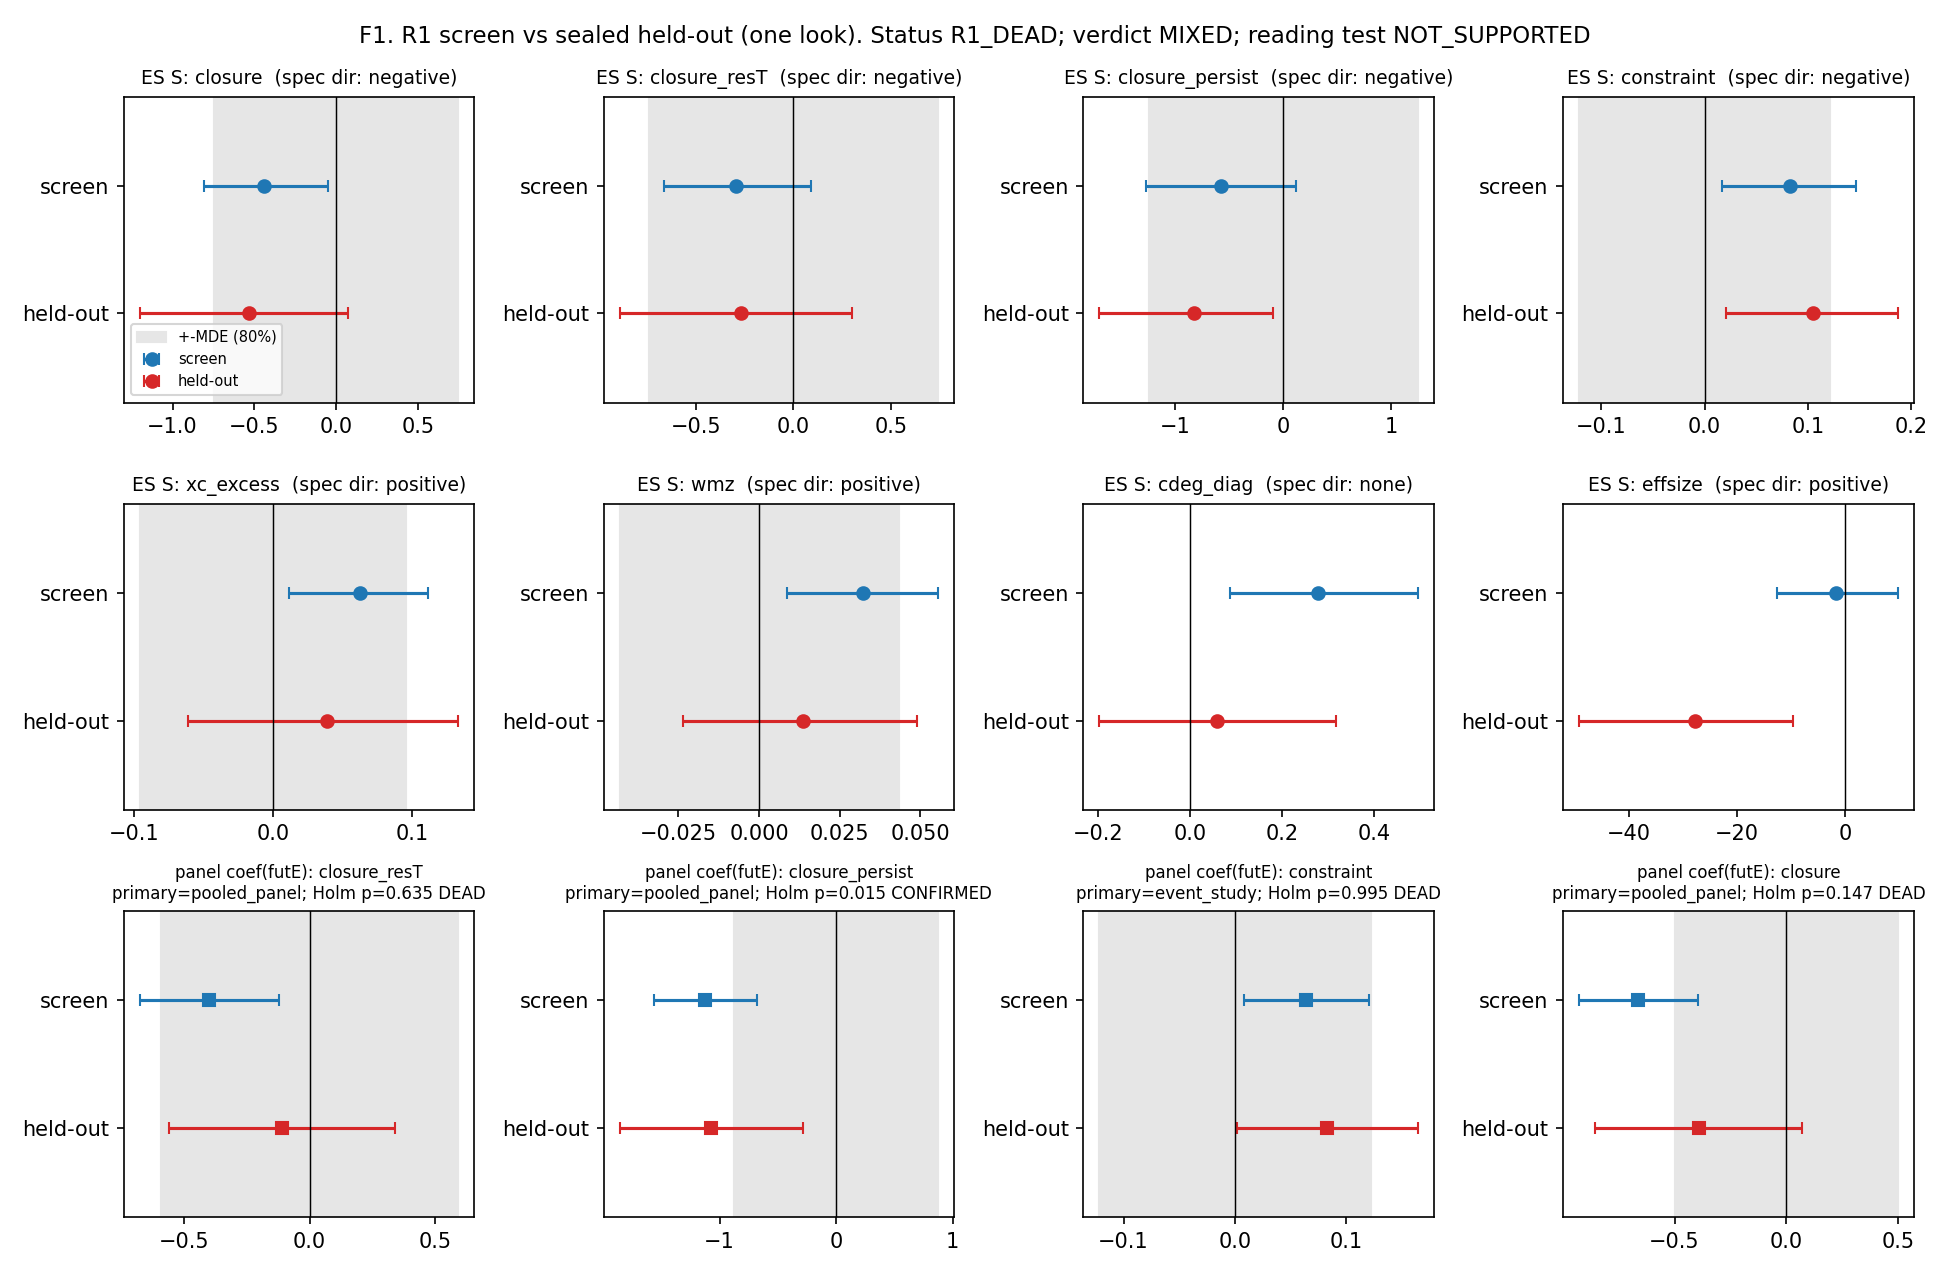

In [16]:
# Forest plot F1 as written by r1_forest()
display(Image(filename=str(FIG / "F1_r1_forest.png")))

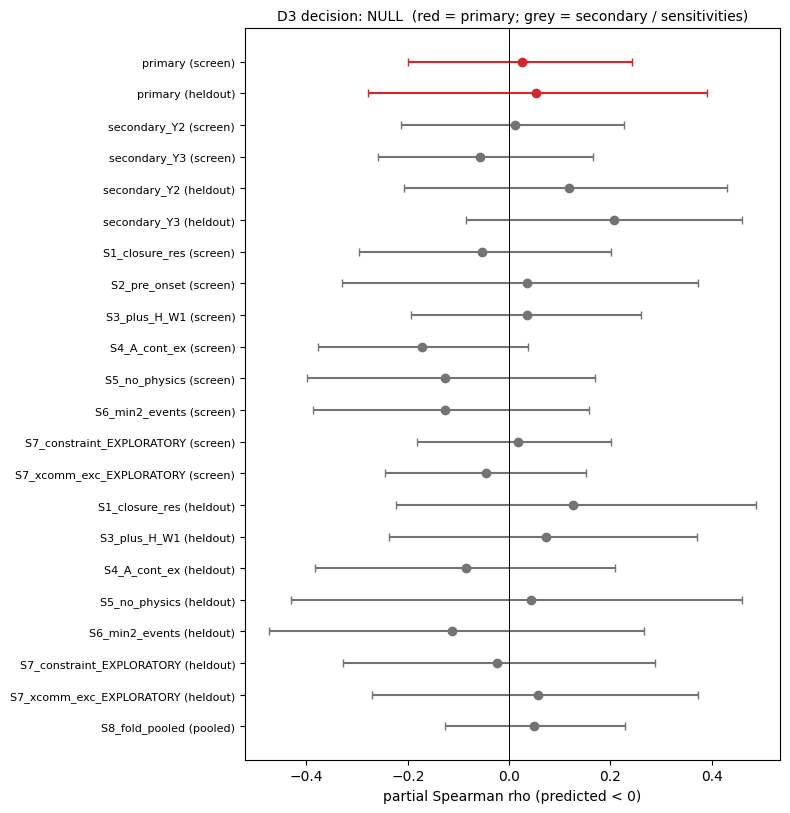

                 analysis    fold   n  partial_rho  ci_lo  ci_hi  p_one_neg    mde
                  primary  screen 102       +0.025 -0.199 +0.242     +0.601 +0.258
                  primary heldout  49       +0.053 -0.279 +0.391     +0.635 +0.380
             secondary_Y2  screen 102       +0.011 -0.213 +0.226     +0.544 +0.258
             secondary_Y3  screen 102       -0.058 -0.258 +0.166     +0.289 +0.258
             secondary_Y2 heldout  49       +0.117 -0.207 +0.431     +0.778 +0.380
             secondary_Y3 heldout  49       +0.207 -0.086 +0.460     +0.914 +0.380
           S1_closure_res  screen  82       -0.054 -0.297 +0.201     +0.327 +0.289
             S2_pre_onset  screen  42       +0.034 -0.331 +0.372     +0.579 +0.413
             S3_plus_H_W1  screen 102       +0.036 -0.193 +0.259     +0.645 +0.259
             S4_A_cont_ex  screen 102       -0.172 -0.377 +0.037     +0.046 +0.258
            S5_no_physics  screen  65       -0.127 -0.400 +0.169     +0.163 +0.324
    

In [17]:
# D3: partial Spearman rho (early closure vs later host-entry anchoring) with bootstrap CI, per analysis and fold
d3_ex = [e for e in out["datasets"][2]["examples"]][:SHOW_N_D3_ROWS]
g = lambda e, k: e.get(k, np.nan)  # some fields are dropped from eval_out when NaN
lab = [f"{e['metadata_analysis']} ({e['metadata_fold']})" for e in d3_ex]
rho = np.array([g(e, "eval_partial_rho") for e in d3_ex])
lo = np.array([g(e, "eval_ci_lo") for e in d3_ex]); hi = np.array([g(e, "eval_ci_hi") for e in d3_ex])
col = ["tab:red" if e["metadata_analysis"] == "primary" else "0.45" for e in d3_ex]

fig, ax = plt.subplots(figsize=(8, 0.32 * len(d3_ex) + 1.2))
y = np.arange(len(d3_ex))[::-1]
for yi, r, l, h, c in zip(y, rho, lo, hi, col):
    ax.errorbar([r], [yi], xerr=[[r - l], [h - r]], fmt="o", color=c, capsize=3)
ax.axvline(0, color="k", lw=0.7)
ax.set_yticks(y, lab, fontsize=8)
ax.set_xlabel("partial Spearman rho (predicted < 0)")
ax.set_title(f"D3 decision: {d3r['decision']['decision']}  (red = primary; grey = secondary / sensitivities)", fontsize=10)
fig.tight_layout(); plt.show()

print(pd.DataFrame([dict(analysis=e["metadata_analysis"], fold=e["metadata_fold"], n=int(g(e, "eval_n")), partial_rho=g(e, "eval_partial_rho"),
                         ci_lo=g(e, "eval_ci_lo"), ci_hi=g(e, "eval_ci_hi"), p_one_neg=g(e, "eval_p_one_neg"), mde=g(e, "eval_mde_rho"))
                    for e in d3_ex]).to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

In [18]:
# D1 descriptive table and the paper-facing results note
print("=== D1 (descriptive only) ===")
print(pd.read_csv(TAB / "d1_heldout_descriptive.csv")[["openness", "outcome", "coef_heldout", "ci_lo", "ci_hi", "p_boot", "coef_screen",
                                                       "sign_agreement_descriptive", "transfer_delta_r2"]].to_string(index=False, float_format=lambda x: f"{x:+.4f}"))
display(Markdown((WS / "results_note.md").read_text()))

=== D1 (descriptive only) ===
         openness  outcome  coef_heldout   ci_lo   ci_hi  p_boot  coef_screen  sign_agreement_descriptive  transfer_delta_r2
    closure_res_z      Y1r       +0.0031 -0.0320 +0.0328 +0.7656      +0.0194                        True            -0.0232
    closure_res_z       Y2       +0.0026 -0.0085 +0.0127 +0.5757      +0.0070                        True            -0.0166
    closure_res_z log1p_Y3       -0.0874 -0.2085 +0.0585 +0.1889      -0.0650                        True            +0.0102
closure_res_imp_z      Y1r       -0.0008 -0.0408 +0.0290 +0.9675      +0.0209                       False            -0.0209
closure_res_imp_z       Y2       +0.0037 -0.0077 +0.0141 +0.5007      +0.0120                        True            -0.0194
closure_res_imp_z log1p_Y3       -0.0746 -0.1597 +0.0362 +0.1479      -0.0262                        True            +0.0048


# Results note (held-out R1, D3)

**Held-out R1 (one look, spec 535c2dd3).** Under the kill mapping frozen before opening, R1 is **R1_DEAD**: the raw-closure pooled-panel coefficient keeps its negative sign (-0.391, one-sided p = 0.049) but fails Holm (p = 0.147); closure_resT is DEAD (Holm p = 0.635); and persistent-neighbour closure is CONFIRMED on the held-out fold (-1.073, Holm p = 0.015). The mechanical verdict is MIXED again, and the reading test is NOT_SUPPORTED. Constraint is positive once more, S = +0.105 [+0.021, +0.187], and xc_excess is S = +0.038 [-0.061, +0.133]. Caveat: the pre-declared fallback fired (fewer than 20 matched), so both estimators also use screen never-concepts as controls. Because raw closure does not survive Holm, the claimed tension between Cheng et al. (2023), where ideas become core through focused discourse and a fit with existing traditions (i.e. higher constraint), and Salatino et al. (2017), where cross-fertilisation of weakly connected areas precedes emergence (sparse, cross-community associates), is moot as a confirmed RQ1 finding. It survives only as a descriptive pattern: the redundant wider ego network (constraint > 0, replicated with CI excluding 0) is closer to Cheng et al., and the persistent top neighbours being less closed is closer to Salatino et al. The RQ1 sentence therefore becomes 'structural precursors are volume/churn correlates', qualified by the confirmed persistent-neighbour row. D3 is **NULL**: partial rho = +0.025 [-0.199, +0.242] on the screen (n = 102, p = 0.60) and +0.053 [-0.279, +0.391] on the held-out fold (n = 49, MDE 0.38). The 'one mechanism at two scales' sentence is dropped, and the paper reports RQ1 and RQ2-D2 as separate findings.
